# LT-CCD Data Preparation for Coherence Stacks

This notebook prepares Sentinel-1 coherence rasters for LT-CCD damage analysis.

## Goal
The notebook:
- scans post-event and baseline folders recursively
- finds all coherence rasters (`*_corr.tif`)
- loads the AOI
- selects a reference raster grid
- reprojects all rasters to the same CRS, resolution, extent, and transform
- clips all rasters to the AOI
- saves standardized rasters into separate `post` and `baseline` output folders
- exports raster inventory and processing summary

## Input
- Post-event coherence folder
- Baseline coherence folder
- AOI vector file

## Output
- Prepared post-event coherence rasters
- Prepared baseline coherence rasters
- Inventory CSV
- Processing summary JSON

## Notes
This notebook performs data preparation only.
No LT-CCD statistics or damage detection are computed here.

In [57]:
import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from rasterio.transform import array_bounds
from shapely.geometry import mapping
import matplotlib.pyplot as plt
from rasterio.features import geometry_mask

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [58]:
# =========================
# INPUT PATHS
# =========================
post_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/SLC_1/25042026_Lebanon_Post")
baseline_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/SLC_1/18022026_Lebanon_Baseline")
confirm_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/SLC_1/25042026_Lebanon_Post")

aoi_path = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_AOI/Lebanon_South_AOI.geojson")
use_confirm_stack = True

# =========================
# OUTPUT ROOT
# =========================
output_root = Path("/Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026")
prepared_post_dir = output_root / "prepared" / "post"
prepared_baseline_dir = output_root / "prepared" / "baseline"
prepared_confirm_dir = output_root / "prepared" / "confirm"
metadata_dir = output_root / "metadata"
preview_dir = output_root / "preview"

prepared_post_dir.mkdir(parents=True, exist_ok=True)
prepared_baseline_dir.mkdir(parents=True, exist_ok=True)
prepared_confirm_dir.mkdir(parents=True, exist_ok=True)
metadata_dir.mkdir(parents=True, exist_ok=True)
preview_dir.mkdir(parents=True, exist_ok=True)

# =========================
# PROCESSING SETTINGS
# =========================
corr_suffix = "_corr.tif"
nodata_value = np.nan
resampling_method = Resampling.bilinear
reference_source = "post"   # options: "post", "baseline"
reference_index = 0         # which raster from the chosen source will define the target grid

print("📋 Configuration loaded:")
print(f"   Post folder: {post_dir}")
print(f"   Baseline folder: {baseline_dir}")
print(f"   AOI path: {aoi_path}")
print(f"   Output root: {output_root}")
print(f"   Raster suffix filter: {corr_suffix}")
print(f"   Reference source: {reference_source}")
print(f"   Reference index: {reference_index}")

📋 Configuration loaded:
   Post folder: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/SLC_1/25042026_Lebanon_Post
   Baseline folder: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/SLC_1/18022026_Lebanon_Baseline
   AOI path: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Row_Data/Lebanon_AOI/Lebanon_South_AOI.geojson
   Output root: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026
   Raster suffix filter: _corr.tif
   Reference source: post
   Reference index: 0


In [59]:
def find_coherence_rasters(folder: Path, suffix: str = "_corr.tif") -> list[Path]:
    """Recursively find valid coherence rasters and ignore hidden/system files."""
    rasters = []
    
    for p in folder.rglob(f"*{suffix}"):
        if not p.is_file():
            continue
        
        # Skip if any part of the path is hidden/system-like
        if any(part.startswith(".") for part in p.parts):
            continue
        
        rasters.append(p)
    
    return sorted(rasters)


def load_aoi(aoi_file: Path) -> gpd.GeoDataFrame:
    """Load AOI and dissolve into a single geometry if needed."""
    gdf = gpd.read_file(aoi_file)
    if gdf.empty:
        raise ValueError(f"AOI file is empty: {aoi_file}")
    if len(gdf) > 1:
        gdf = gdf.dissolve().reset_index(drop=True)
    return gdf


def get_raster_info(raster_path: Path) -> dict:
    """Read basic raster metadata."""
    with rasterio.open(raster_path) as src:
        return {
            "path": str(raster_path),
            "name": raster_path.name,
            "crs": str(src.crs),
            "width": src.width,
            "height": src.height,
            "count": src.count,
            "dtype": src.dtypes[0],
            "nodata": src.nodata,
            "bounds": tuple(src.bounds),
            "res_x": src.transform.a,
            "res_y": src.transform.e,
            "transform": tuple(src.transform),
        }


def choose_reference_raster(post_files: list[Path], baseline_files: list[Path], source: str = "post", index: int = 0) -> Path:
    """Select reference raster for target grid."""
    if source == "post":
        candidates = post_files
    elif source == "baseline":
        candidates = baseline_files
    else:
        raise ValueError("reference_source must be either 'post' or 'baseline'")
    
    if len(candidates) == 0:
        raise ValueError(f"No files available in reference source: {source}")
    
    if index >= len(candidates):
        raise IndexError(f"reference_index={index} is out of range for {source} files")
    
    return candidates[index]


def clip_bounds_to_aoi(reference_raster_path: Path, aoi_gdf: gpd.GeoDataFrame):
    """Compute AOI bounds in reference raster CRS."""
    with rasterio.open(reference_raster_path) as src:
        aoi_in_ref = aoi_gdf.to_crs(src.crs)
        bounds = aoi_in_ref.total_bounds
        return src.crs, aoi_in_ref, bounds


def build_target_grid_from_reference(reference_raster_path: Path, aoi_gdf: gpd.GeoDataFrame):
    """
    Build target grid from the reference raster and AOI.
    The output grid uses:
    - reference CRS
    - reference resolution
    - AOI-clipped extent
    """
    with rasterio.open(reference_raster_path) as src:
        aoi_in_ref = aoi_gdf.to_crs(src.crs)
        geoms = [mapping(geom) for geom in aoi_in_ref.geometry]
        
        clipped_data, clipped_transform = mask(
            src,
            geoms,
            crop=True,
            nodata=src.nodata if src.nodata is not None else np.nan
        )
        
        target_profile = src.profile.copy()
        target_profile.update({
            "height": clipped_data.shape[1],
            "width": clipped_data.shape[2],
            "transform": clipped_transform,
            "crs": src.crs,
            "count": 1,
            "dtype": "float32",
            "nodata": np.nan,
            "compress": "lzw"
        })
        
    return target_profile, aoi_in_ref


def prepare_single_raster(
    input_path: Path,
    output_path: Path,
    aoi_gdf: gpd.GeoDataFrame,
    target_profile: dict,
    resampling: Resampling = Resampling.bilinear
) -> dict:
    """
    Reproject raster to target grid and clip implicitly by the target grid.
    """
    with rasterio.open(input_path) as src:
        src_array = src.read(1).astype("float32")
        
        # Convert input nodata to NaN if needed
        if src.nodata is not None:
            src_array = np.where(src_array == src.nodata, np.nan, src_array)

        dst_array = np.full(
            (target_profile["height"], target_profile["width"]),
            np.nan,
            dtype="float32"
        )

        reproject(
            source=src_array,
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=np.nan,
            dst_transform=target_profile["transform"],
            dst_crs=target_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling
        )

        valid_pixels = int(np.sum(~np.isnan(dst_array)))
        total_pixels = int(dst_array.size)

        output_profile = target_profile.copy()
        output_profile.update({
            "driver": "GTiff",
            "count": 1,
            "dtype": "float32",
            "nodata": np.nan,
            "compress": "lzw"
        })

        with rasterio.open(output_path, "w", **output_profile) as dst:
            dst.write(dst_array, 1)

    return {
        "input_name": input_path.name,
        "output_name": output_path.name,
        "input_path": str(input_path),
        "output_path": str(output_path),
        "valid_pixels": valid_pixels,
        "total_pixels": total_pixels,
        "valid_percent": round(valid_pixels / total_pixels * 100, 2) if total_pixels > 0 else 0.0,
    }


def make_output_name(input_path: Path, prefix: str) -> str:
    """Create standardized output filename."""
    stem = input_path.stem
    return f"{prefix}_{stem}.tif"


def preview_raster(raster_path: Path, aoi_gdf: gpd.GeoDataFrame, title: str):
    """Quick raster preview."""
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype("float32")
        bounds = src.bounds
        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

        aoi_plot = aoi_gdf.to_crs(src.crs)

        fig, ax = plt.subplots(figsize=(8, 8))
        im = ax.imshow(arr, cmap="viridis", vmin=0, vmax=1, extent=extent)
        aoi_plot.boundary.plot(ax=ax, color="red", linewidth=1.5)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        plt.colorbar(im, ax=ax, shrink=0.7, label="Coherence")
        plt.tight_layout()
        plt.show()

def filter_valid_tifs(file_list):
    """Remove macOS system files and invalid tif files."""
    valid = []
    skipped = []
    
    for p in file_list:
        name = p.name
        
        if name.startswith("._") or name.startswith(".") or name == ".DS_Store":
            skipped.append(name)
            continue
        
        valid.append(p)
    
    return sorted(valid), skipped


from rasterio.windows import Window
from rasterio.windows import transform as window_transform


def reproject_raster_to_target_array(
    input_path: Path,
    target_profile: dict,
    resampling: Resampling = Resampling.bilinear
) -> np.ndarray:
    """Reproject raster to the target grid and return it as an array."""
    with rasterio.open(input_path) as src:
        src_array = src.read(1).astype("float32")

        if src.nodata is not None:
            src_array = np.where(src_array == src.nodata, np.nan, src_array)

        dst_array = np.full(
            (target_profile["height"], target_profile["width"]),
            np.nan,
            dtype="float32"
        )

        reproject(
            source=src_array,
            destination=dst_array,
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=np.nan,
            dst_transform=target_profile["transform"],
            dst_crs=target_profile["crs"],
            dst_nodata=np.nan,
            resampling=resampling
        )

    return dst_array


def get_valid_bbox(arr: np.ndarray):
    """Return bounding box of valid pixels as row_min, row_max, col_min, col_max."""
    valid_mask = ~np.isnan(arr)

    if not np.any(valid_mask):
        raise ValueError("Raster contains no valid pixels after reprojection.")

    rows, cols = np.where(valid_mask)

    return rows.min(), rows.max(), cols.min(), cols.max()


def get_common_valid_bbox(arrays: list[np.ndarray]):
    """
    Compute common intersection bbox of valid data coverage across all rasters.
    """
    bboxes = [get_valid_bbox(arr) for arr in arrays]

    row_min = max(b[0] for b in bboxes)
    row_max = min(b[1] for b in bboxes)
    col_min = max(b[2] for b in bboxes)
    col_max = min(b[3] for b in bboxes)

    if row_min >= row_max or col_min >= col_max:
        raise ValueError("No common valid overlap found across all rasters.")

    return row_min, row_max, col_min, col_max


from rasterio.features import geometry_mask

def crop_array_and_profile(
    arr: np.ndarray,
    target_profile: dict,
    bbox: tuple[int, int, int, int],
    aoi_gdf: gpd.GeoDataFrame
):
    """Crop array to common bbox and mask pixels outside AOI."""
    row_min, row_max, col_min, col_max = bbox

    cropped = arr[row_min:row_max + 1, col_min:col_max + 1]

    window = Window(
        col_off=col_min,
        row_off=row_min,
        width=cropped.shape[1],
        height=cropped.shape[0]
    )

    cropped_transform = window_transform(window, target_profile["transform"])

    cropped_profile = target_profile.copy()
    cropped_profile.update({
        "height": cropped.shape[0],
        "width": cropped.shape[1],
        "transform": cropped_transform,
        "driver": "GTiff",
        "count": 1,
        "dtype": "float32",
        "nodata": np.nan,
        "compress": "lzw"
    })

    aoi_in_raster_crs = aoi_gdf.to_crs(target_profile["crs"])
    geoms = [mapping(geom) for geom in aoi_in_raster_crs.geometry]

    outside_aoi_mask = geometry_mask(
        geoms,
        out_shape=cropped.shape,
        transform=cropped_transform,
        invert=False
    )

    cropped = np.where(outside_aoi_mask, np.nan, cropped)

    return cropped, cropped_profile


def save_prepared_raster(
    arr: np.ndarray,
    output_path: Path,
    profile: dict
):
    """Save prepared raster."""
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(arr.astype("float32"), 1)

In [60]:
print("🔎 Scanning input folders for coherence rasters...")

post_files = find_coherence_rasters(post_dir, corr_suffix)
baseline_files = find_coherence_rasters(baseline_dir, corr_suffix)

print(f"   ✅ Post rasters found: {len(post_files)}")
for p in post_files[:5]:
    print(f"      - {p.name}")
if len(post_files) > 5:
    print("      ...")

print(f"\n   ✅ Baseline rasters found: {len(baseline_files)}")
for p in baseline_files[:5]:
    print(f"      - {p.name}")
if len(baseline_files) > 5:
    print("      ...")

if use_confirm_stack:
    confirm_files = find_coherence_rasters(confirm_dir, corr_suffix)
    print(f"   ✅ Confirmation rasters found: {len(confirm_files)}")
    for p in confirm_files[:5]:
        print(f"      - {p.name}")
    if len(confirm_files) > 5:
        print("      ...")
else:
    confirm_files = []

if len(post_files) == 0:
    raise ValueError(f"No coherence rasters found in post folder: {post_dir}")
if len(baseline_files) == 0:
    raise ValueError(f"No coherence rasters found in baseline folder: {baseline_dir}")
if len(confirm_files) == 0 and use_confirm_stack:
    raise ValueError(f"No coherence rasters found in confirm folder: {confirm_dir}")

🔎 Scanning input folders for coherence rasters...
   ✅ Post rasters found: 24
      - S1AC_20250903T033536_20260425T033431_VVR234_INT40_G_ueF_C007_corr.tif
      - S1AC_20250915T033537_20260425T033431_VVR222_INT40_G_ueF_34F9_corr.tif
      - S1AC_20250927T033537_20260425T033431_VVR210_INT40_G_ueF_357B_corr.tif
      - S1AC_20251114T033536_20260425T033431_VVR162_INT40_G_ueF_FFAD_corr.tif
      - S1AC_20260125T033529_20260425T033431_VVR090_INT40_G_ueF_974E_corr.tif
      ...

   ✅ Baseline rasters found: 23
      - S1AA_20250822T033536_20260218T033528_VVP180_INT40_G_ueF_208F_corr.tif
      - S1AA_20250903T033536_20260218T033528_VVP168_INT40_G_ueF_454B_corr.tif
      - S1AA_20250915T033537_20260218T033528_VVP156_INT40_G_ueF_7D02_corr.tif
      - S1AA_20251021T033537_20260218T033528_VVP120_INT40_G_ueF_E131_corr.tif
      - S1AA_20251102T033537_20260218T033528_VVP108_INT40_G_ueF_64A3_corr.tif
      ...
   ✅ Confirmation rasters found: 24
      - S1AC_20250903T033536_20260425T033431_VVR234_I

In [61]:
print("🗺️ Loading AOI...")

aoi_gdf = load_aoi(aoi_path)

print(f"   ✅ AOI loaded successfully")
print(f"   Features: {len(aoi_gdf)}")
print(f"   CRS: {aoi_gdf.crs}")
print(f"   Bounds: {aoi_gdf.total_bounds}")

🗺️ Loading AOI...
   ✅ AOI loaded successfully
   Features: 1
   CRS: EPSG:4326
   Bounds: [35.10348737 33.05499679 35.59716936 33.40749535]


In [62]:
print("📂 Reading raster metadata...")

post_inventory = pd.DataFrame([get_raster_info(p) for p in post_files])
post_inventory["group"] = "post"

baseline_inventory = pd.DataFrame([get_raster_info(p) for p in baseline_files])
baseline_inventory["group"] = "baseline"

inventory = pd.concat([post_inventory, baseline_inventory], ignore_index=True)

print(f"   ✅ Inventory created with {len(inventory)} rasters")
display(inventory[["group", "name", "crs", "width", "height", "dtype"]].head(10))

📂 Reading raster metadata...
   ✅ Inventory created with 47 rasters


,group,name,crs,width,height,dtype
0,post,S1AC_20250903T033536_20260425T033431_VVR234_IN...,EPSG:32637,7347,5839,float32
1,post,S1AC_20250915T033537_20260425T033431_VVR222_IN...,EPSG:32637,7347,5841,float32
2,post,S1AC_20250927T033537_20260425T033431_VVR210_IN...,EPSG:32637,7347,5839,float32
3,post,S1AC_20251114T033536_20260425T033431_VVR162_IN...,EPSG:32637,7347,5841,float32
4,post,S1AC_20260125T033529_20260425T033431_VVR090_IN...,EPSG:32637,7347,5839,float32
5,post,S1AC_20260314T033528_20260425T033431_VVR042_IN...,EPSG:32637,7347,5839,float32
6,post,S1AC_20260326T033528_20260425T033431_VVR030_IN...,EPSG:32637,7345,5839,float32
7,post,S1CC_20250711T033431_20260425T033431_VVR288_IN...,EPSG:32637,7323,5835,float32
8,post,S1CC_20250723T033431_20260425T033431_VVR276_IN...,EPSG:32637,7323,5835,float32
9,post,S1CC_20250804T033432_20260425T033431_VVR264_IN...,EPSG:32637,7323,5833,float32


In [63]:
print("🎯 Selecting reference raster...")

reference_raster = choose_reference_raster(
    post_files=post_files,
    baseline_files=baseline_files,
    source=reference_source,
    index=reference_index
)

print(f"   ✅ Reference raster selected: {reference_raster.name}")

target_profile, aoi_in_target_crs = build_target_grid_from_reference(reference_raster, aoi_gdf)

print("\n📊 Target grid:")
print(f"   CRS: {target_profile['crs']}")
print(f"   Width: {target_profile['width']}")
print(f"   Height: {target_profile['height']}")
print(f"   Transform: {target_profile['transform']}")
print(f"   Resolution X: {target_profile['transform'].a}")
print(f"   Resolution Y: {target_profile['transform'].e}")

target_bounds = array_bounds(
    target_profile["height"],
    target_profile["width"],
    target_profile["transform"]
)

print(f"   Bounds: {target_bounds}")

🎯 Selecting reference raster...
   ✅ Reference raster selected: S1AC_20250903T033536_20260425T033431_VVR234_INT40_G_ueF_C007_corr.tif

📊 Target grid:
   CRS: EPSG:32637
   Width: 1172
   Height: 989
   Transform: | 40.00, 0.00, 136260.00|
| 0.00,-40.00, 3702740.00|
| 0.00, 0.00, 1.00|
   Resolution X: 40.0
   Resolution Y: -40.0
   Bounds: (136260.0, 3663180.0, 183140.0, 3702740.0)


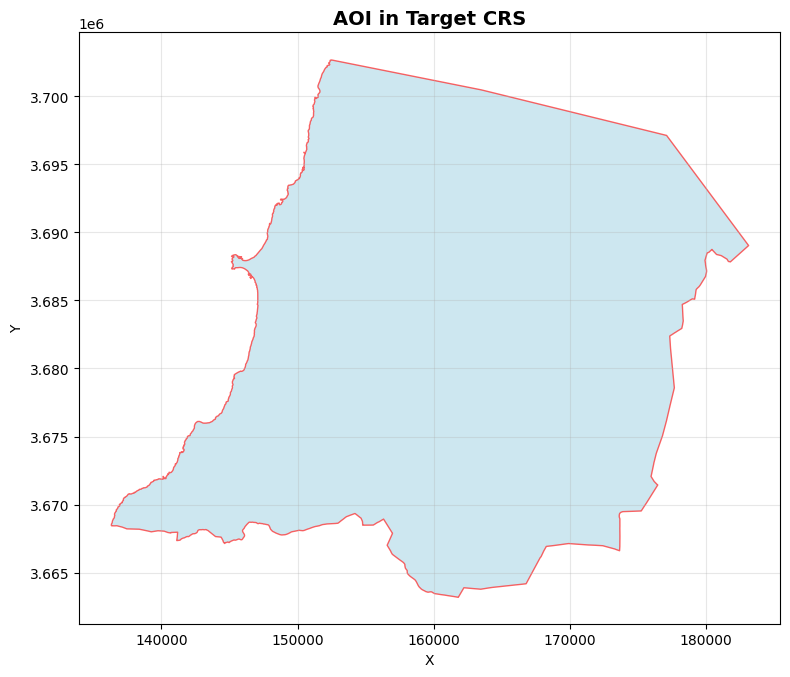

In [64]:
fig, ax = plt.subplots(figsize=(8, 8))
aoi_in_target_crs.plot(ax=ax, facecolor="lightblue", edgecolor="red", alpha=0.6)
ax.set_title("AOI in Target CRS", fontsize=14, fontweight="bold")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
print("🔄 Reprojecting all rasters to target grid...")

all_files = (
    [(p, "post") for p in post_files] +
    [(p, "baseline") for p in baseline_files] +
    [(p, "confirm") for p in confirm_files]
)

reprojected_data = []

for idx, (raster_path, group) in enumerate(all_files, start=1):
    print(f"\n   [{idx}/{len(all_files)}] Reprojecting {group.upper()} raster:")
    print(f"      Input: {raster_path.name}")

    arr = reproject_raster_to_target_array(
        input_path=raster_path,
        target_profile=target_profile,
        resampling=resampling_method
    )

    valid_pixels = int(np.sum(~np.isnan(arr)))
    total_pixels = int(arr.size)

    reprojected_data.append({
        "input_path": raster_path,
        "group": group,
        "array": arr,
        "valid_pixels_before_common_crop": valid_pixels,
        "total_pixels_before_common_crop": total_pixels,
        "valid_percent_before_common_crop": round(valid_pixels / total_pixels * 100, 2)
    })

    print(f"      Valid pixels before common crop: {valid_pixels:,} / {total_pixels:,}")


print("\n✂️ Finding common valid extent across POST + BASELINE + CONFIRM rasters...")

common_bbox = get_common_valid_bbox([item["array"] for item in reprojected_data])

row_min, row_max, col_min, col_max = common_bbox

print("   ✅ Common valid bbox found:")
print(f"      Rows: {row_min} → {row_max}")
print(f"      Cols: {col_min} → {col_max}")
print(f"      Final height: {row_max - row_min + 1}")
print(f"      Final width:  {col_max - col_min + 1}")


print("\n💾 Cropping all rasters to common valid extent and saving...")

post_results = []
baseline_results = []
confirm_results = []

for idx, item in enumerate(reprojected_data, start=1):
    raster_path = item["input_path"]
    group = item["group"]
    arr = item["array"]

    if group == "post":
        prefix = "post"
        output_path = prepared_post_dir / make_output_name(raster_path, prefix=prefix)
    elif group == "baseline":
        prefix = "baseline"
        output_path = prepared_baseline_dir / make_output_name(raster_path, prefix=prefix)
    elif group == "confirm":
        prefix = "confirm"
        output_path = prepared_confirm_dir / make_output_name(raster_path, prefix=prefix)
    else:
        raise ValueError(f"Unknown group: {group}")
    output_name = output_path.name

    cropped_arr, cropped_profile = crop_array_and_profile(
        arr=arr,
        target_profile=target_profile,
        bbox=common_bbox,
        aoi_gdf=aoi_gdf
    )

    save_prepared_raster(
        arr=cropped_arr,
        output_path=output_path,
        profile=cropped_profile
    )

    valid_pixels = int(np.sum(~np.isnan(cropped_arr)))
    total_pixels = int(cropped_arr.size)

    result = {
        "input_name": raster_path.name,
        "output_name": output_name,
        "input_path": str(raster_path),
        "output_path": str(output_path),
        "group": group,
        "valid_pixels": valid_pixels,
        "total_pixels": total_pixels,
        "valid_percent": round(valid_pixels / total_pixels * 100, 2) if total_pixels > 0 else 0.0,
        "height": cropped_arr.shape[0],
        "width": cropped_arr.shape[1],
        "valid_pixels_before_common_crop": item["valid_pixels_before_common_crop"],
        "valid_percent_before_common_crop": item["valid_percent_before_common_crop"]
    }

    if group == "post":
        post_results.append(result)
    elif group == "baseline":
        baseline_results.append(result)
    elif group == "confirm":
        confirm_results.append(result)

    print(f"\n   [{idx}/{len(reprojected_data)}] Saved {group.upper()} raster:")
    print(f"      Output: {output_name}")
    print(f"      Final shape: {cropped_arr.shape}")
    print(f"      Valid pixels: {valid_pixels:,} / {total_pixels:,} ({result['valid_percent']}%)")

print("\n✅ All POST and BASELINE rasters prepared with common valid extent")

🔄 Reprojecting all rasters to target grid...

   [1/71] Reprojecting POST raster:
      Input: S1AC_20250903T033536_20260425T033431_VVR234_INT40_G_ueF_C007_corr.tif
      Valid pixels before common crop: 1,159,108 / 1,159,108

   [2/71] Reprojecting POST raster:
      Input: S1AC_20250915T033537_20260425T033431_VVR222_INT40_G_ueF_34F9_corr.tif
      Valid pixels before common crop: 1,159,108 / 1,159,108

   [3/71] Reprojecting POST raster:
      Input: S1AC_20250927T033537_20260425T033431_VVR210_INT40_G_ueF_357B_corr.tif
      Valid pixels before common crop: 1,159,108 / 1,159,108

   [4/71] Reprojecting POST raster:
      Input: S1AC_20251114T033536_20260425T033431_VVR162_INT40_G_ueF_FFAD_corr.tif
      Valid pixels before common crop: 1,159,108 / 1,159,108

   [5/71] Reprojecting POST raster:
      Input: S1AC_20260125T033529_20260425T033431_VVR090_INT40_G_ueF_974E_corr.tif
      Valid pixels before common crop: 1,159,108 / 1,159,108

   [6/71] Reprojecting POST raster:
      Input: 

In [66]:
print("📦 Building prepared raster inventory...")

prepared_inventory = pd.DataFrame(post_results + baseline_results + confirm_results)

print(f"   ✅ Prepared inventory created")
print(f"   Total prepared rasters: {len(prepared_inventory)}")
print(f"   POST rasters: {np.sum(prepared_inventory['group'] == 'post')}")
print(f"   BASELINE rasters: {np.sum(prepared_inventory['group'] == 'baseline')}")
print(f"   CONFIRM rasters: {np.sum(prepared_inventory['group'] == 'confirm')}")

display(prepared_inventory.head(10))

📦 Building prepared raster inventory...
   ✅ Prepared inventory created
   Total prepared rasters: 71
   POST rasters: 24
   BASELINE rasters: 23
   CONFIRM rasters: 24


,input_name,output_name,input_path,output_path,group,valid_pixels,total_pixels,valid_percent,height,width,valid_pixels_before_common_crop,valid_percent_before_common_crop
0,S1AC_20250903T033536_20260425T033431_VVR234_IN...,post_S1AC_20250903T033536_20260425T033431_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
1,S1AC_20250915T033537_20260425T033431_VVR222_IN...,post_S1AC_20250915T033537_20260425T033431_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
2,S1AC_20250927T033537_20260425T033431_VVR210_IN...,post_S1AC_20250927T033537_20260425T033431_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
3,S1AC_20251114T033536_20260425T033431_VVR162_IN...,post_S1AC_20251114T033536_20260425T033431_VVR1...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
4,S1AC_20260125T033529_20260425T033431_VVR090_IN...,post_S1AC_20260125T033529_20260425T033431_VVR0...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
5,S1AC_20260314T033528_20260425T033431_VVR042_IN...,post_S1AC_20260314T033528_20260425T033431_VVR0...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
6,S1AC_20260326T033528_20260425T033431_VVR030_IN...,post_S1AC_20260326T033528_20260425T033431_VVR0...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
7,S1CC_20250711T033431_20260425T033431_VVR288_IN...,post_S1CC_20250711T033431_20260425T033431_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
8,S1CC_20250723T033431_20260425T033431_VVR276_IN...,post_S1CC_20250723T033431_20260425T033431_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0
9,S1CC_20250804T033432_20260425T033431_VVR264_IN...,post_S1CC_20250804T033432_20260425T033431_VVR2...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,/Volumes/ChaikaT7/LT_CCD_damage_assessment/Reg...,post,677107,1159108,58.42,989,1172,1159108,100.0


In [67]:
print("🔍 Running quality checks...")

post_prepared_raw = list(prepared_post_dir.glob("*.tif"))
baseline_prepared_raw = list(prepared_baseline_dir.glob("*.tif"))

post_prepared_files, skipped_post = filter_valid_tifs(post_prepared_raw)
baseline_prepared_files, skipped_baseline = filter_valid_tifs(baseline_prepared_raw)

confirm_prepared_raw = list(prepared_confirm_dir.glob("*.tif"))
confirm_prepared_files, skipped_confirm = filter_valid_tifs(confirm_prepared_raw)

print("🔍 Filtering prepared rasters:")
print(f"   POST valid: {len(post_prepared_files)} | skipped: {len(skipped_post)}")
print(f"   BASELINE valid: {len(baseline_prepared_files)} | skipped: {len(skipped_baseline)}")
print(f"   CONFIRM valid: {len(confirm_prepared_files)} | skipped: {len(skipped_confirm)}")

if len(skipped_post) > 0:
    print(f"   ⚠️ Skipped POST system files: {skipped_post[:3]}...")
if len(skipped_baseline) > 0:
    print(f"   ⚠️ Skipped BASELINE system files: {skipped_baseline[:3]}...")
if len(skipped_confirm) > 0:
    print(f"   ⚠️ Skipped CONFIRM system files: {skipped_confirm[:3]}...")

if len(post_prepared_files) == 0 or len(baseline_prepared_files) == 0:
    raise ValueError("Prepared raster folders are empty after processing.")
if use_confirm_stack and len(confirm_prepared_files) == 0:
    raise ValueError("Prepared confirmation folder is empty after processing.")

sample_files = [post_prepared_files[0], baseline_prepared_files[0]]

for sample in sample_files:
    with rasterio.open(sample) as src:
        print(f"\n   File: {sample.name}")
        print(f"      CRS: {src.crs}")
        print(f"      Shape: ({src.height}, {src.width})")
        print(f"      Transform: {src.transform}")
        print(f"      Bounds: {src.bounds}")

print("\n✅ Quality check completed")

🔍 Running quality checks...
🔍 Filtering prepared rasters:
   POST valid: 24 | skipped: 24
   BASELINE valid: 23 | skipped: 23
   CONFIRM valid: 24 | skipped: 24
   ⚠️ Skipped POST system files: ['._post_S1AC_20250903T033536_20260425T033431_VVR234_INT40_G_ueF_C007_corr.tif', '._post_S1AC_20250915T033537_20260425T033431_VVR222_INT40_G_ueF_34F9_corr.tif', '._post_S1AC_20250927T033537_20260425T033431_VVR210_INT40_G_ueF_357B_corr.tif']...
   ⚠️ Skipped BASELINE system files: ['._baseline_S1AA_20250822T033536_20260218T033528_VVP180_INT40_G_ueF_208F_corr.tif', '._baseline_S1AA_20250903T033536_20260218T033528_VVP168_INT40_G_ueF_454B_corr.tif', '._baseline_S1AA_20250915T033537_20260218T033528_VVP156_INT40_G_ueF_7D02_corr.tif']...
   ⚠️ Skipped CONFIRM system files: ['._confirm_S1AC_20250903T033536_20260425T033431_VVR234_INT40_G_ueF_C007_corr.tif', '._confirm_S1AC_20250915T033537_20260425T033431_VVR222_INT40_G_ueF_34F9_corr.tif', '._confirm_S1AC_20250927T033537_20260425T033431_VVR210_INT40_G_ueF

🖼️ Visualizing sample prepared rasters...


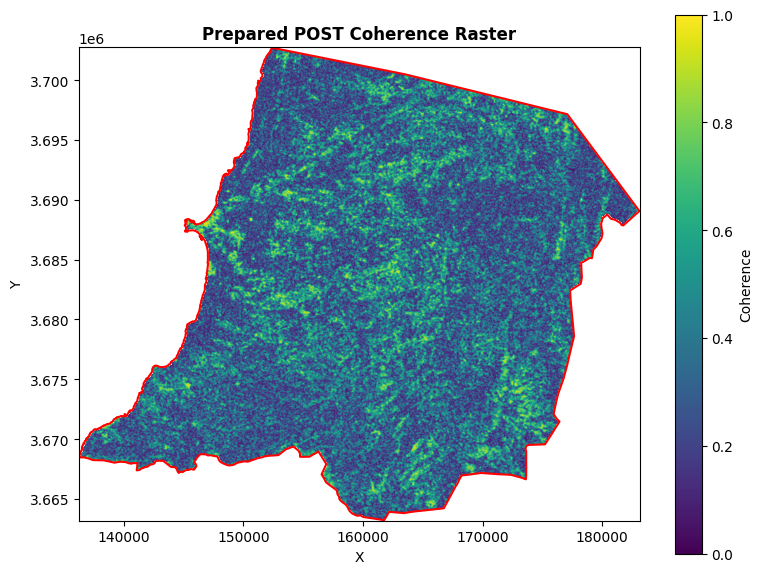

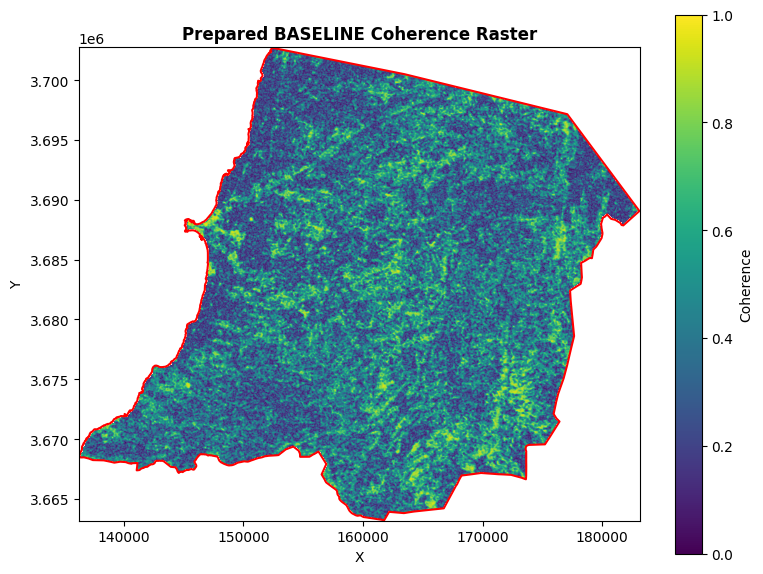

In [68]:
print("🖼️ Visualizing sample prepared rasters...")

preview_raster(post_prepared_files[0], aoi_gdf, "Prepared POST Coherence Raster")
preview_raster(baseline_prepared_files[0], aoi_gdf, "Prepared BASELINE Coherence Raster")

In [69]:
print("💾 Saving metadata and processing summary...")

inventory_csv_path = metadata_dir / "prepared_raster_inventory.csv"
inventory_json_path = metadata_dir / "prepared_raster_inventory.json"
summary_json_path = metadata_dir / "preparation_summary.json"

prepared_inventory.to_csv(inventory_csv_path, index=False)
prepared_inventory.to_json(inventory_json_path, orient="records", indent=2)

summary = {
    "processing_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "aoi_path": str(aoi_path),
    "post_input_dir": str(post_dir),
    "baseline_input_dir": str(baseline_dir),
    "output_root": str(output_root),
    "reference_source": reference_source,
    "reference_index": reference_index,
    "reference_raster": str(reference_raster),
    "target_crs": str(target_profile["crs"]),
    "original_target_width": int(target_profile["width"]),
    "original_target_height": int(target_profile["height"]),
    "final_common_width": int(col_max - col_min + 1),
    "final_common_height": int(row_max - row_min + 1),
    "target_transform": list(target_profile["transform"]),
    "n_post_input": len(post_files),
    "n_baseline_input": len(baseline_files),
    "n_post_prepared": int(np.sum(prepared_inventory["group"] == "post")),
    "n_baseline_prepared": int(np.sum(prepared_inventory["group"] == "baseline")),
    "prepared_post_dir": str(prepared_post_dir),
    "prepared_baseline_dir": str(prepared_baseline_dir),
    "common_crop_row_min": int(row_min),
    "common_crop_row_max": int(row_max),
    "common_crop_col_min": int(col_min),
    "common_crop_col_max": int(col_max),
    "common_crop_width": int(col_max - col_min + 1),
    "common_crop_height": int(row_max - row_min + 1),
    "confirm_input_dir": str(confirm_dir) if use_confirm_stack else None,
    "n_confirm_input": len(confirm_files),
    "n_confirm_prepared": int(np.sum(prepared_inventory["group"] == "confirm")),
    "prepared_confirm_dir": str(prepared_confirm_dir),
    "use_confirm_stack": use_confirm_stack,
}

with open(summary_json_path, "w") as f:
    json.dump(summary, f, indent=2)

print(f"   ✅ Inventory CSV saved: {inventory_csv_path}")
print(f"   ✅ Inventory JSON saved: {inventory_json_path}")
print(f"   ✅ Summary JSON saved: {summary_json_path}")

💾 Saving metadata and processing summary...
   ✅ Inventory CSV saved: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/metadata/prepared_raster_inventory.csv
   ✅ Inventory JSON saved: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/metadata/prepared_raster_inventory.json
   ✅ Summary JSON saved: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/metadata/preparation_summary.json


In [70]:
print("🎉 LT-CCD data preparation completed successfully!")

print("\n📋 Final Summary:")
print(f"   AOI file: {aoi_path.name}")
print(f"   Reference raster: {reference_raster.name}")
print(f"   Target CRS: {target_profile['crs']}")
print(f"   Target shape: {target_profile['height']} x {target_profile['width']}")
print(f"   Prepared POST rasters: {len(post_results)}")
print(f"   Prepared BASELINE rasters: {len(baseline_results)}")
print(f"   Prepared CONFIRM rasters: {len(confirm_results)}")

print("\n📁 Output folders:")
print(f"   POST prepared rasters: {prepared_post_dir}")
print(f"   BASELINE prepared rasters: {prepared_baseline_dir}")
print(f"   CONFIRM prepared rasters: {prepared_confirm_dir}")
print(f"   Metadata: {metadata_dir}")

print("\n🔄 Ready for Notebook 2: LT-CCD stack statistics and damage detection")

🎉 LT-CCD data preparation completed successfully!

📋 Final Summary:
   AOI file: Lebanon_South_AOI.geojson
   Reference raster: S1AC_20250903T033536_20260425T033431_VVR234_INT40_G_ueF_C007_corr.tif
   Target CRS: EPSG:32637
   Target shape: 989 x 1172
   Prepared POST rasters: 24
   Prepared BASELINE rasters: 23
   Prepared CONFIRM rasters: 24

📁 Output folders:
   POST prepared rasters: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/prepared/post
   BASELINE prepared rasters: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/prepared/baseline
   CONFIRM prepared rasters: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/prepared/confirm
   Metadata: /Volumes/ChaikaT7/LT_CCD_damage_assessment/Regions/Lebanon/Data/Prepared_Data/Lebanon_South/SLC_1/Prepared_25042026/metadata

🔄 Ready for No